In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


### Import Library yang Dibutuhkan

### Menampilkan Gambar yang Sudah Dipisahkan Channelnya Menjadi 3 Yaitu RGB
Hasil pemisahan kanal warna menunjukkan bahwa citra asal memiliki distribusi yang berbeda secara signifikan pada tiap komponen RGB. Visualisasi ini membuktikan adanya ketidakseimbangan intensitas, di mana tiap kanal menyimpan informasi spasial yang berbeda, yang kemudian dikonfirmasi melalui grafik histogram masing-masing kanal.

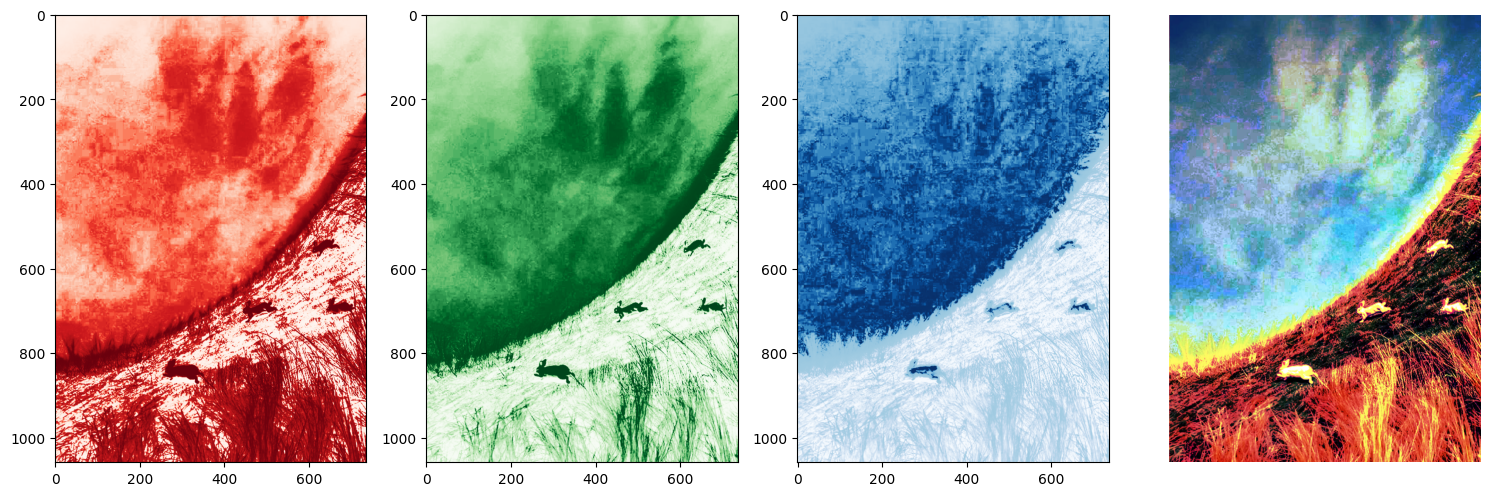

In [57]:
img_rgb = cv2.imread('Assets/background.png')

image_red   = img_rgb[:, :, 0]
image_green = img_rgb[:, :, 1]
image_blue  = img_rgb[:, :, 2]

plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(image_red, cmap='Reds')

plt.subplot(1, 4, 2)
plt.imshow(image_green, cmap='Greens')

plt.subplot(1, 4, 3)
plt.imshow(image_blue, cmap='Blues')

plt.subplot(1, 4, 4)
plt.imshow(img_rgb, cmap='grey')
plt.axis('off')

plt.tight_layout()
plt.show()

In [58]:
def buat_hist(citra): 
    histogram = [0] * 256 
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1   
 
    return histogram 
def plot_histogram(histogram, title, ImgColor): 
   
    plt.xlabel("Intensitas Piksel") 
    plt.title(title) 
    plt.ylabel("Jumlah Piksel") 
    plt.bar(range(256), histogram, color=ImgColor, width=0.8) 
    plt.show() 

### Penjelasan Fungsi Histogram Citra
Fungsi buat_hist digunakan untuk menghitung frekuensi kemunculan setiap nilai intensitas piksel (0–255) dalam sebuah citra ke dalam sebuah daftar histogram, sementara fungsi plot_histogram memvisualisasikan data tersebut ke dalam bentuk diagram batang menggunakan pustaka Matplotlib dengan label dan warna yang dapat ditentukan.

### Menampilkan Hasil Histogram
Grafik histogram citra asal memperlihatkan adanya penumpukan piksel pada rentang intensitas tertentu. Ketidakteraturan sebaran ini menjelaskan mengapa citra terlihat terlalu pucat atau memiliki kontras yang rendah, sehingga diperlukan proses perbaikan distribusi untuk menyeimbangkan intensitasnya

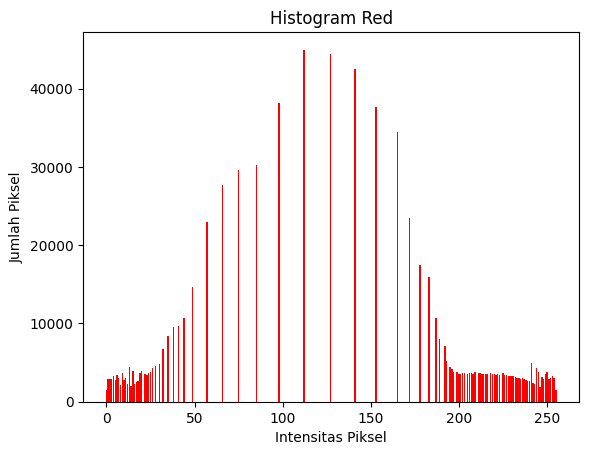

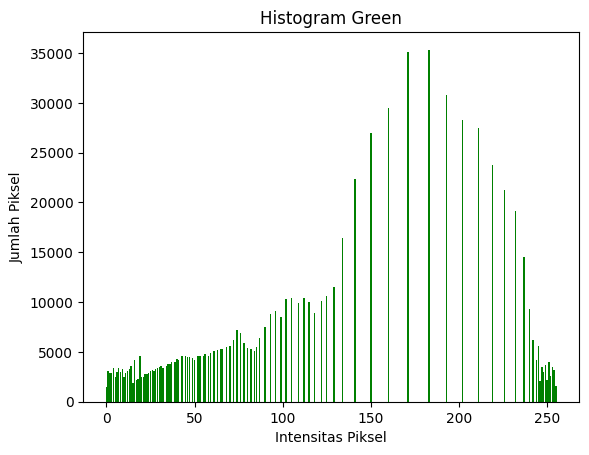

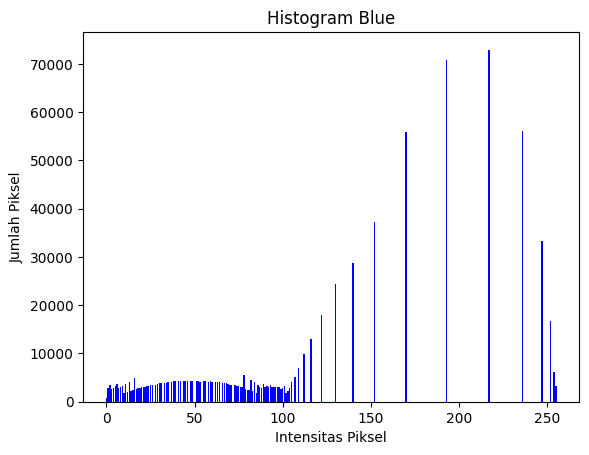

In [59]:
hist_data = buat_hist(image_red)
plot_histogram(hist_data, "Histogram Red", "red")

hist_data = buat_hist(image_green)
plot_histogram(hist_data, "Histogram Green", "green")

hist_data = buat_hist(image_blue)
plot_histogram(hist_data, "Histogram Blue", "blue")



### Menampilkan Gambar Target
Analisis terhadap citra target menunjukkan profil histogram yang lebih ideal dengan sebaran intensitas yang lebih merata. Profil inilah yang digunakan sebagai acuan dalam proses spesifikasi histogram agar citra asal dapat mengadaptasi karakteristik warna dan pencahayaan dari citra target tersebut.

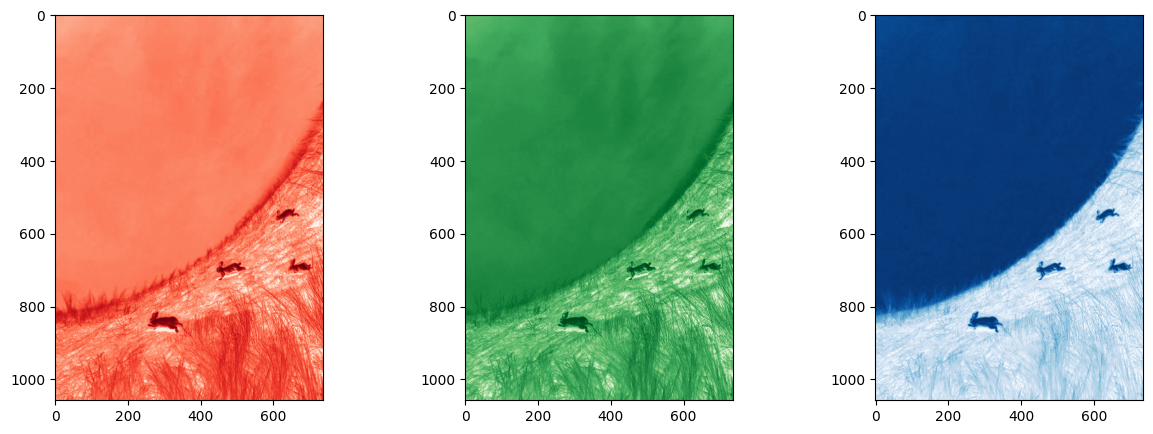

In [60]:
t_red = cv2.imread('Assets/red_target.png')
t_green = cv2.imread('Assets/green_target.png')
t_blue = cv2.imread('Assets/blue_target.png')

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(t_red[:, :, 2], cmap='Reds')

plt.subplot(1, 3, 2)
plt.imshow(t_green[:, :, 1], cmap='Greens') 

plt.subplot(1, 3, 3)
plt.imshow(t_blue[:, :, 0], cmap='Blues')


plt.show()

### Menampilkan Histogram dari Citra Target

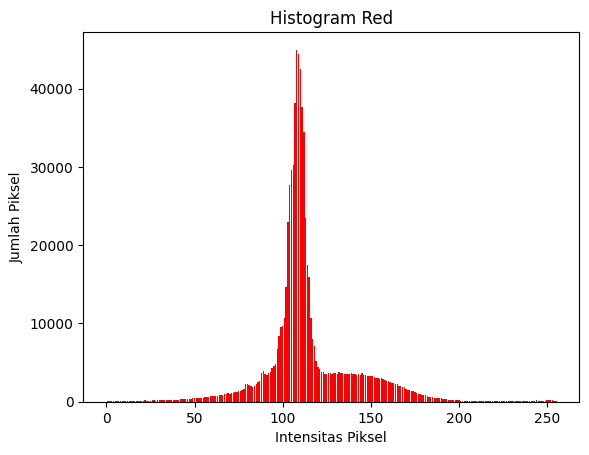

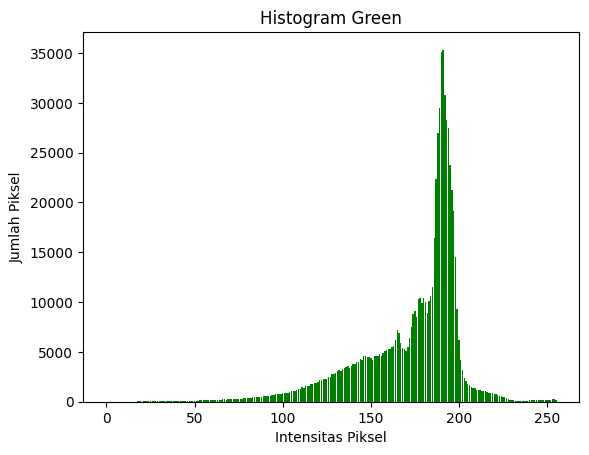

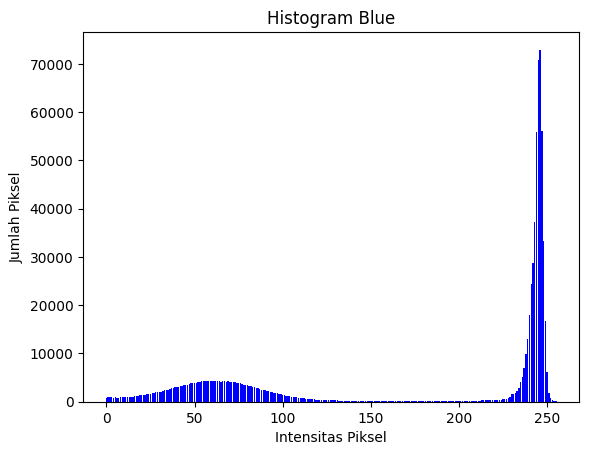

In [61]:
target_red_channel   = t_red[:, :, 2]
target_green_channel = t_green[:, :, 1]
target_blue_channel  = t_blue[:, :, 0]  

hist_data_r = buat_hist(target_red_channel)
plot_histogram(hist_data_r, "Histogram Red", "red")


hist_data_g = buat_hist(target_green_channel)
plot_histogram(hist_data_g, "Histogram Green", "green")


hist_data_b = buat_hist(target_blue_channel)
plot_histogram(hist_data_b, "Histogram Blue", "blue")

plt.show()

In [62]:
def spesifikasi_histogram(citra_asal, citra_target): 
   
    if citra_asal.max() <= 1.0 and citra_asal.dtype != np.uint8:
        citra_asal = (citra_asal * 255).astype(np.uint8)
    else:
        citra_asal = citra_asal.astype(np.uint8)

    if citra_target.max() <= 1.0 and citra_target.dtype != np.uint8:
        citra_target = (citra_target * 255).astype(np.uint8)
    else:
        citra_target = citra_target.astype(np.uint8)

    hist_asal = np.zeros(256, dtype=int) 
    for i in range(citra_asal.shape[0]):
        for j in range(citra_asal.shape[1]):
            hist_asal[citra_asal[i, j]] += 1
    
    hist_target = np.zeros(256, dtype=int) 
    for i in range(citra_target.shape[0]):
        for j in range(citra_target.shape[1]):
            hist_target[citra_target[i, j]] += 1

    cdf_asal = np.zeros(256, dtype=float) 
    cdf_target = np.zeros(256, dtype=float) 
    cdf_asal[0] = hist_asal[0] 
    cdf_target[0] = hist_target[0] 

    for k in range(1, 256):
        cdf_asal[k] = cdf_asal[k-1] + hist_asal[k]
        cdf_target[k] = cdf_target[k-1] + hist_target[k]

    cdf_asal = cdf_asal / cdf_asal[-1] 
    cdf_target = cdf_target / cdf_target[-1] 

    map_hist = np.zeros(256, dtype=np.uint8) 
    for i in range(256):
        selisih = np.abs(cdf_asal[i] - cdf_target)
        j_terdekat = np.argmin(selisih)
        map_hist[i] = j_terdekat

    height, width = citra_asal.shape 
    hasil = np.zeros((height, width), dtype=np.uint8) 
    for i in range(height):
        for j in range(width):
            hasil[i, j] = map_hist[citra_asal[i, j]]

    return hasil 

### Spesifikasi Histogram Citra Digital
Fungsi spesifikasi_histogram melakukan transformasi nilai piksel dari citra asal agar memiliki distribusi warna yang mengikuti pola citra target dengan cara menormalisasi rentang nilai kedua citra ke format 8-bit, menghitung serta membandingkan fungsi distribusi kumulatif (CDF) masing-masing, dan memetakan setiap piksel asal ke nilai terdekat pada target guna mencapai karakteristik visual yang serupa.

### Menampilkan Histogram dari Citra Hasil Spesifikasi
Hasil transformasi menunjukkan perubahan warna pada objek yang kini lebih menyerupai citra referensi. Selain itu, penerapan operasi dilatasi pada objek orang berhasil mempertegas bagian tepi dan mengisi celah kecil pada piksel objek

<Figure size 1500x500 with 0 Axes>

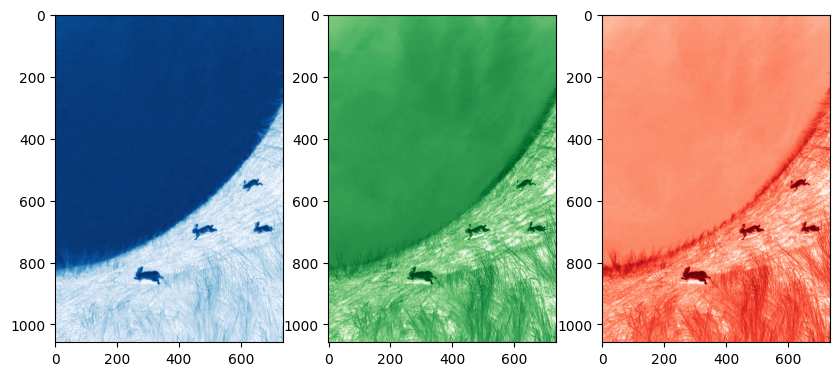

In [63]:
matched_R = spesifikasi_histogram(image_red, target_red_channel)
matched_G = spesifikasi_histogram(image_green, target_green_channel)
matched_B = spesifikasi_histogram(image_blue, target_blue_channel)

plt.figure(figsize=(15, 5))

plt.figure(figsize=(10, 5))

plt.subplot(1,3,1)
plt.imshow(matched_B, cmap="Blues")

plt.subplot(1,3,2)
plt.imshow(matched_G, cmap="Greens")

plt.subplot(1,3,3)
plt.imshow(matched_R, cmap="Reds")

plt.show()

### Menampilkan Citra dari Penggabungan Channel RGB yang Diproses Sebelumnya

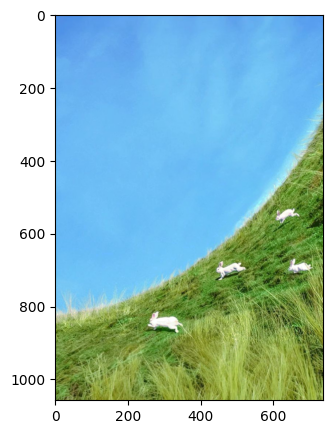

In [64]:
def gabung(r, g, b):
    height, width = r.shape
    citra_gabung = np.zeros((height, width, 3), dtype=np.uint8)

    for i in range(height):
        for j in range(width):
            citra_gabung[i, j, 0] = r[i, j] 
            citra_gabung[i, j, 1] = g[i, j] 
            citra_gabung[i, j, 2] = b[i, j] 
            
    return citra_gabung

padang_gabung = gabung(matched_R, matched_G, matched_B)

plt.figure(figsize=(10, 5))
plt.imshow(padang_gabung)
plt.show()

### Menampilkan Citra Foreground.png

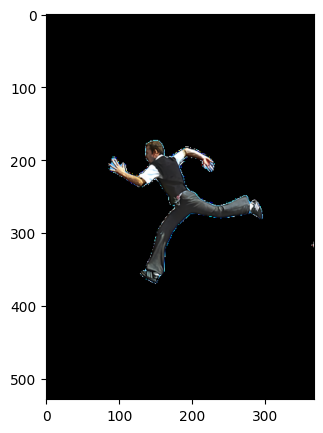

In [65]:
manusia = cv2.imread("Assets/foreground.png")
manusia = cv2.cvtColor(manusia, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))
plt.imshow(manusia)
plt.show()

### Menampilkan Hasil dari Proses Dilatasi Untuk Mempertegas Bagian-Bagian Tertentu pada Citra

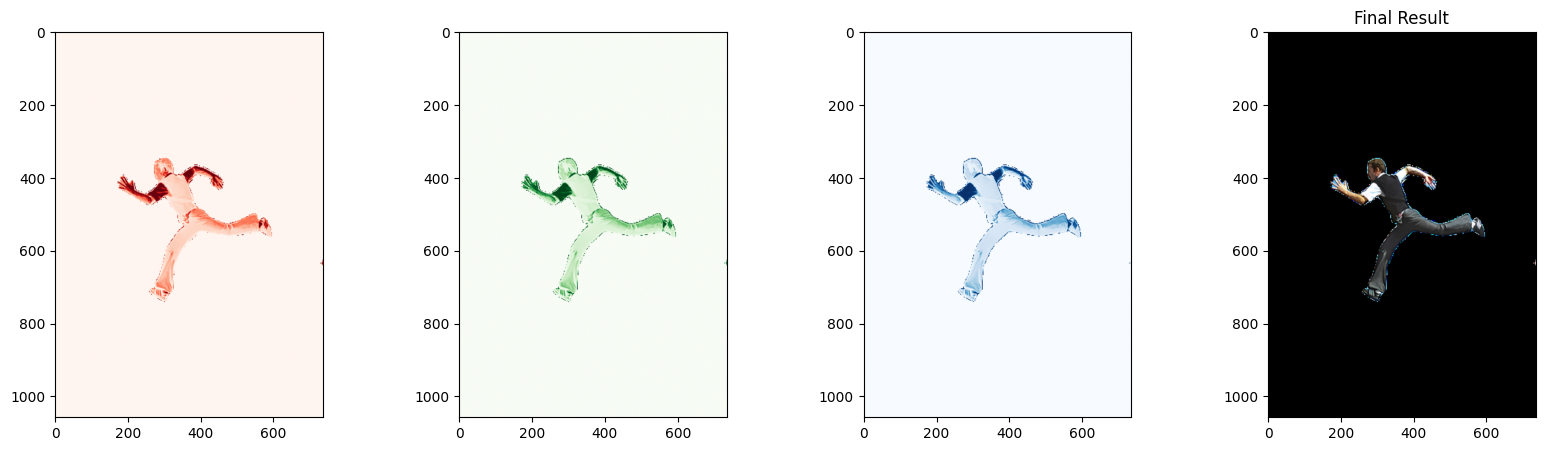

In [66]:
manusia_red = manusia[:, :, 0]
manusia_green = manusia[:, :, 1]
manusia_blue = manusia[:, :, 2]

def dilatasi_crop(image, atas=0, bawah=0, kiri=0, kanan=0):
    h, w = image.shape

    hasil = np.zeros((h*2, w*2), dtype=image.dtype)

    for i in range(h*2):
        for j in range(w*2):
            hasil[i,j] = image[int(i/2), int(j/2)]

    hasil_crop = hasil[atas:h*2-bawah, kiri:w*2-kanan]
    return hasil_crop

orang_d1 = dilatasi_crop(manusia_red, 0, 0, 0, 0)
orang_d2 = dilatasi_crop(manusia_green, 0, 0, 0, 0)
orang_d3 = dilatasi_crop(manusia_blue, 0, 0, 0, 0)

orang_gabung = gabung(orang_d1, orang_d2, orang_d3)

plt.figure(figsize=(20, 5))

plt.subplot(1,4,1)
plt.imshow(orang_d1, cmap="Reds")

plt.subplot(1,4,2)
plt.imshow(orang_d2, cmap="Greens")

plt.subplot(1,4,3)
plt.imshow(orang_d3, cmap="Blues")

plt.subplot(1,4,4)
plt.title("Final Result")
plt.imshow(orang_gabung)

plt.show()

### Menampilkan Citra Hasil Penggabungan

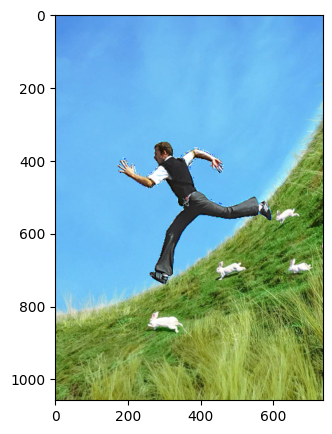

In [67]:
def masking_citra(background, foreground):
    height, width, channels = background.shape

    hasil_masking = np.zeros((height, width, 3), dtype=np.uint8)

    for i in range(height):
        for j in range(width):
            if foreground[i, j, 0] > 0 or foreground[i, j, 1] > 0 or foreground[i, j, 2] > 0:
                hasil_masking[i, j] = foreground[i, j]
            else:
                hasil_masking[i, j] = background[i, j]
                
    return hasil_masking

orang_padang = masking_citra(padang_gabung, orang_gabung)

plt.figure(figsize=(10, 5))
plt.imshow(orang_padang)
plt.show()

### Menampilkan Histogram Citra Penggabungan

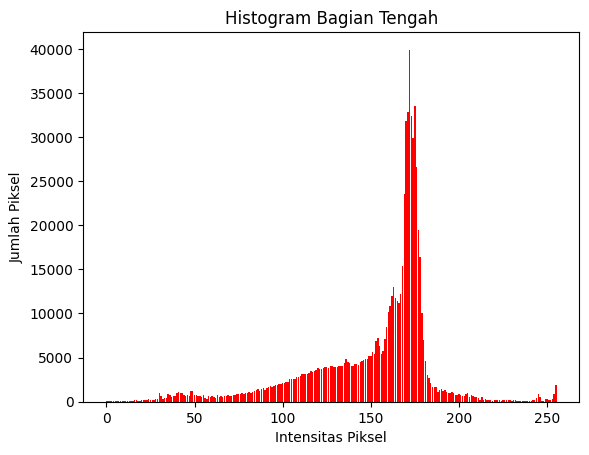

In [68]:
orang_padang_gray = cv2.cvtColor(orang_padang, cv2.COLOR_RGB2GRAY)

hist_data_g = buat_hist(orang_padang_gray)
plot_histogram(hist_data_g, "Histogram Bagian Tengah", "red")

### Menampilkan Citra yang Sudah Dipotong Menjadi 3 Bagian

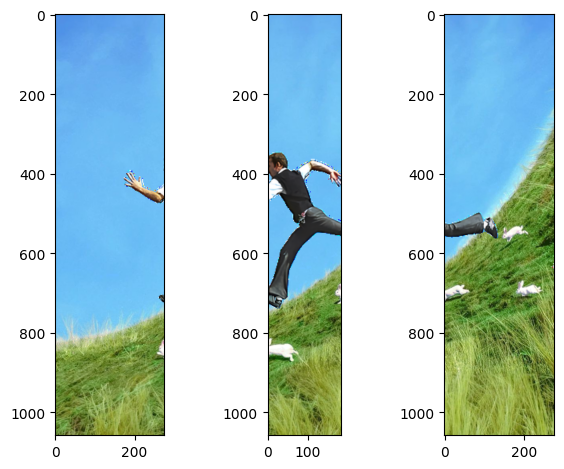

In [69]:
kiri = orang_padang[ :, 0:275]
tengah = orang_padang[ :, 275:460]
kanan = orang_padang[ :, 460:]

plt.subplot(1, 3, 1)
plt.imshow(kiri)

plt.subplot(1, 3, 2)
plt.imshow(tengah)

plt.subplot(1, 3, 3)
plt.imshow(kanan)

plt.tight_layout()

### Menggabungkan Histogram Citra Bagian Tengah

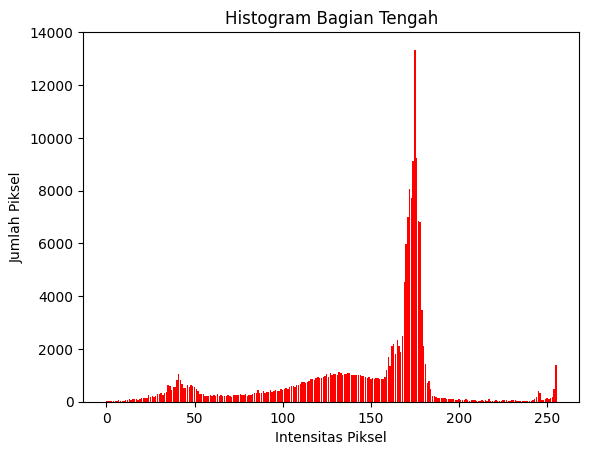

In [70]:
tengah_gray = cv2.cvtColor(tengah, cv2.COLOR_RGB2GRAY)
hist_data = buat_hist(tengah_gray)
plot_histogram(hist_data, "Histogram Bagian Tengah", "red")

### Menampilkan Citra yang diekualisasi
Analisis pada bagian tengah citra yang dipotong menunjukkan bahwa meskipun telah melalui tahap spesifikasi, distribusi pencahayaannya masih bisa dioptimalkan. Proses ekualisasi histogram yang diterapkan pada area ini berhasil meningkatkan kontras secara signifikan, yang terlihat dari grafik histogram akhir yang lebih tersebar luas di seluruh rentang intensitas (0-255).

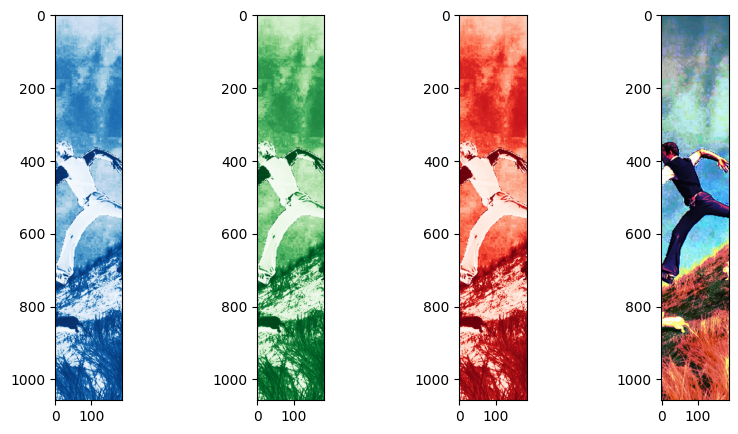

In [71]:
tengah_red = tengah[:, :, 0]
tengah_green = tengah[:, :, 1]
tengah_blue = tengah[:, :, 2]

def ekualisasi_histogram(citra):
    panjang, lebar = citra.shape

    # Hitung histogram
    histogram = np.zeros(256, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            nilai = citra[i, j]
            histogram[nilai] += 1

    # Hitung CDF
    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(histogram[:i+1])

    # Normalisasi CDF
    cdf_min = cdf[cdf > 0].min() if np.any(cdf > 0) else 0
    cdf_norm = np.round((cdf - cdf_min) / (panjang * lebar - cdf_min) * 255).astype(int)

    # Petakan nilai baru
    hasil = np.zeros_like(citra, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            val = citra[i, j]
            hasil[i, j] = cdf_norm[val]

    return hasil

tengah_blue = ekualisasi_histogram(tengah_blue)
tengah_green = ekualisasi_histogram(tengah_green)
tengah_red = ekualisasi_histogram(tengah_red)

gabung_tengah = gabung(tengah_blue, tengah_green, tengah_red)
gabung_tengah = cv2.cvtColor(gabung_tengah, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(1, 4, 1)
plt.imshow(tengah_red, cmap="Blues")

plt.subplot(1, 4, 2)
plt.imshow(tengah_red, cmap="Greens")

plt.subplot(1, 4, 3)
plt.imshow(tengah_red, cmap="Reds")

plt.subplot(1, 4, 4)
plt.imshow(gabung_tengah)

plt.show()

### Menampilkan Histogram Citra Bagian Tengah

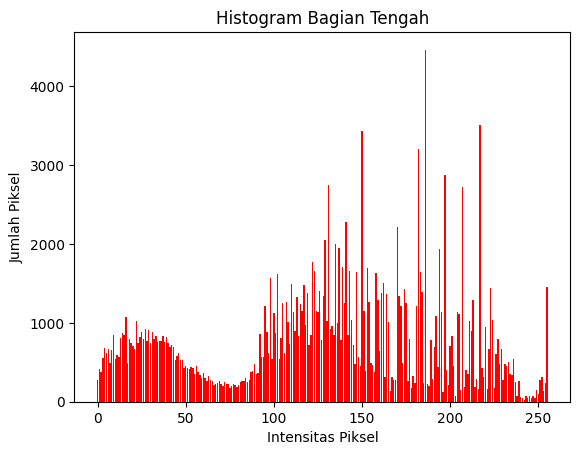

In [72]:
gabung_tengah_gray = cv2.cvtColor(gabung_tengah, cv2.COLOR_RGB2GRAY)
hist_data = buat_hist(gabung_tengah_gray)
plot_histogram(hist_data, "Histogram Bagian Tengah", "red")

### Menampilkan citra yang digabungkan dengan bagian kiri dan kanan seperti sebelumnya, namun bagian tengah diganti dengan hasil ekualisasi

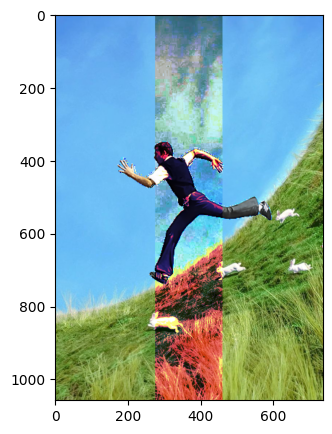

In [73]:
def mergehori (img1, img2):
    tinggi = max(img1.shape[0], img2.shape[0])
    lebar = img1.shape[1] + img2.shape[1]

    if len(img1.shape) == 2 :
        hasil = np.zeros((tinggi, lebar), dtype = img1.dtype)
    else :
        hasil = np.zeros((tinggi, lebar,img1.shape[2]), dtype=img1.dtype)
    hasil[0:img1.shape[0], 0:img1.shape[1]] = img1
    hasil[0:img2.shape[0], img1.shape[1]:img1.shape[1]+img2.shape[1]] = img2
    
    return hasil

def mergever (img1, img2):
    tinggi = img1.shape[0] + img2.shape[0]
    lebar = max(img1.shape[1], img2.shape[1])
    if len(img1.shape) == 2 :
        hasil = np.zeros((tinggi, lebar), dtype = img1.dtype)
    else :
        hasil = np.zeros((tinggi, lebar, img1.shape[2]), dtype = img1.dtype)
    hasil[0:img1.shape[0], 0:img1.shape[1]] = img1
    hasil[img1.shape[0]:img1.shape[0]+img2.shape[0], 0:img2.shape[1]] = img2
   
    return hasil

orang_lari_sebagian = mergehori(kiri, gabung_tengah)
orang_fix = mergehori (orang_lari_sebagian, kanan)

plt.figure(figsize=(10,5))
plt.imshow(orang_fix)
plt.show()

### Menampilkan Histogram Citra yang Digabungkan

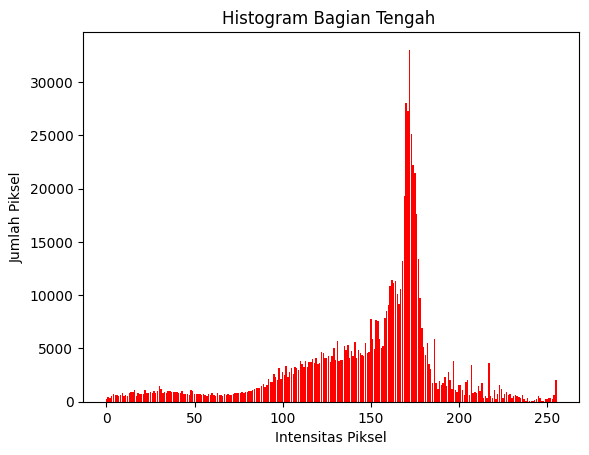

In [74]:
orangfix = cv2.cvtColor(orang_fix, cv2.COLOR_RGB2GRAY)
hist_data = buat_hist(orangfix)
plot_histogram(hist_data, "Histogram Bagian Tengah ", "red")

# Kesimpulan
Kesimpulan dari seluruh proses ini adalah bahwa kombinasi teknik manipulasi histogram, seperti spesifikasi untuk menyelaraskan warna dengan citra target dan ekualisasi untuk meningkatkan kontras, terbukti efektif dalam memperbaiki kualitas visual citra yang awalnya tidak seimbang. Melalui tahapan analisis kanal RGB, perbaikan struktur objek dengan dilatasi, hingga penggabungan kembali area citra yang telah dioptimalkan, dihasilkan transformasi citra yang lebih harmonis dengan distribusi intensitas piksel yang merata dan detail objek yang jauh lebih tegas.